In [1]:
!pip install squarify

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import squarify

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [29]:
df = pd.read_csv("/content/insurance.csv")

df = df.iloc[:,0].str.split(",", expand=True)

df.columns = [
    "age",
    "gender",
    "bmi",
    "children",
    "smoker",
    "region",
    "charges"
]

df["age"] = pd.to_numeric(df["age"])
df["bmi"] = pd.to_numeric(df["bmi"])
df["children"] = pd.to_numeric(df["children"])
df["charges"] = pd.to_numeric(df["charges"])

df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

print()

df.describe()

print()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB




,0
age,0
gender,0
bmi,0
children,0
smoker,0
region,0
charges,0


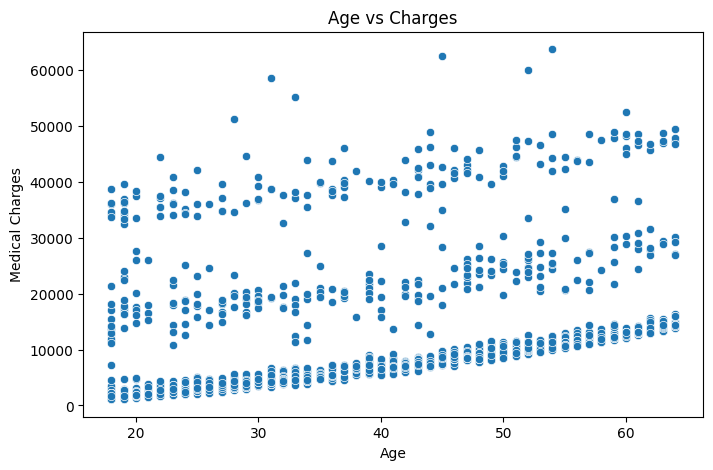

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    data=df
)

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.show()

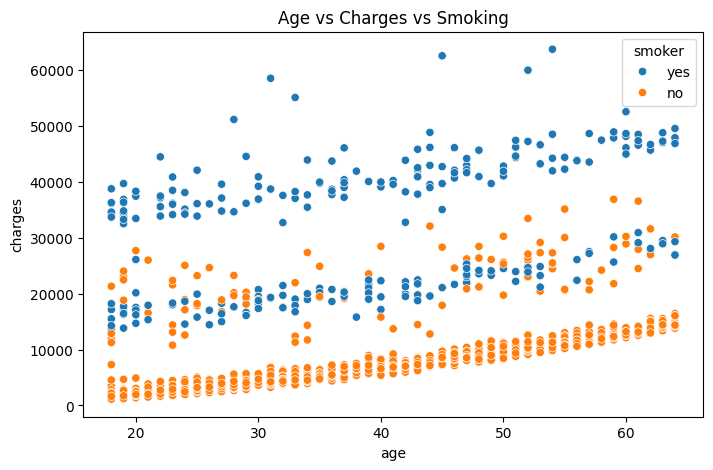

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    hue='smoker',
    data=df
)

plt.title("Age vs Charges vs Smoking")

plt.show()

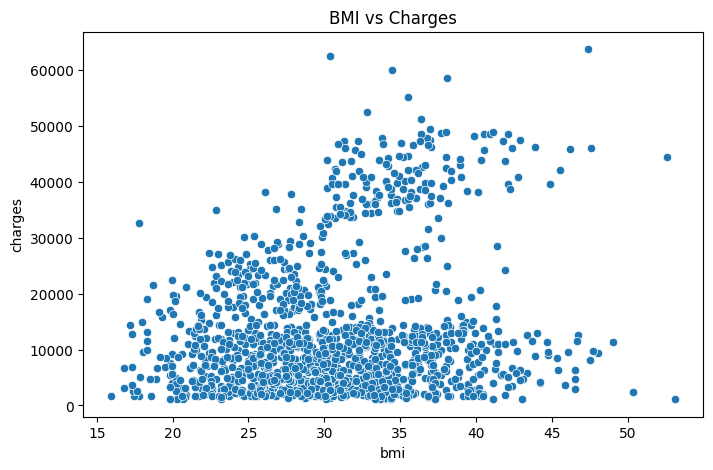

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bmi',
    y='charges',
    data=df
)

plt.title("BMI vs Charges")

plt.show()

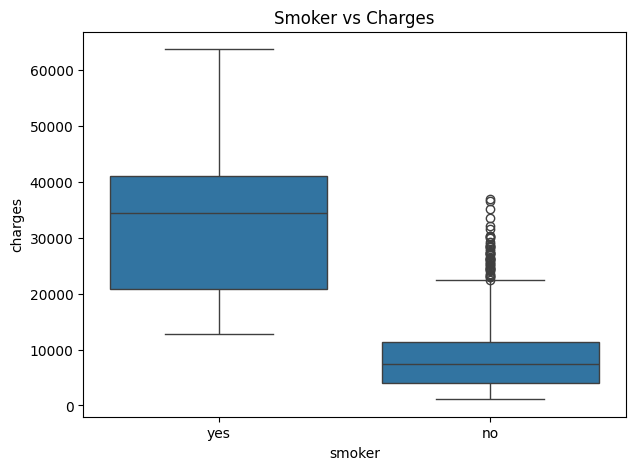

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title("Smoker vs Charges")

plt.show()

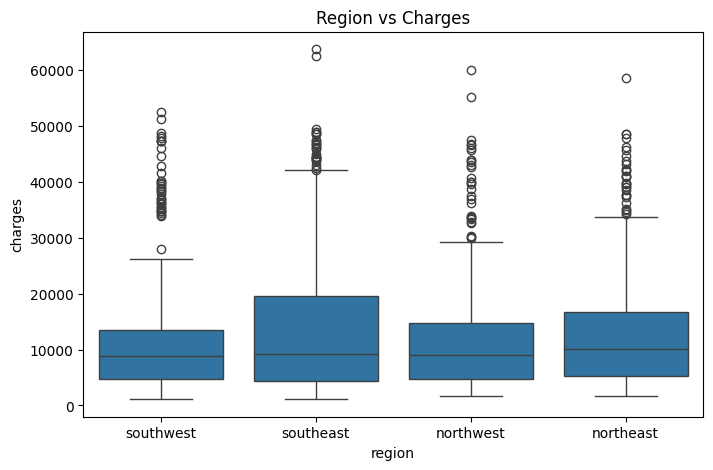

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='region',
    y='charges',
    data=df
)

plt.title("Region vs Charges")

plt.show()

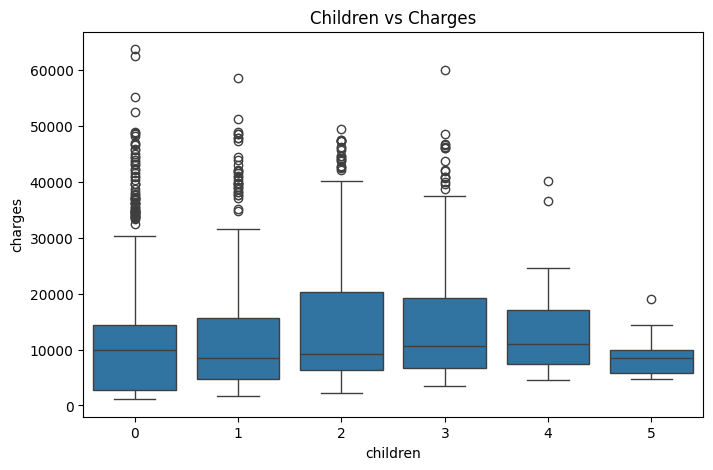

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='children',
    y='charges',
    data=df
)

plt.title("Children vs Charges")

plt.show()

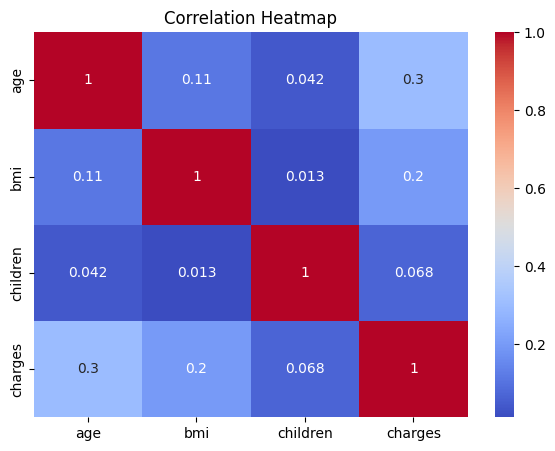

In [16]:
numeric = df[['age','bmi','children','charges']]

plt.figure(figsize=(7,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

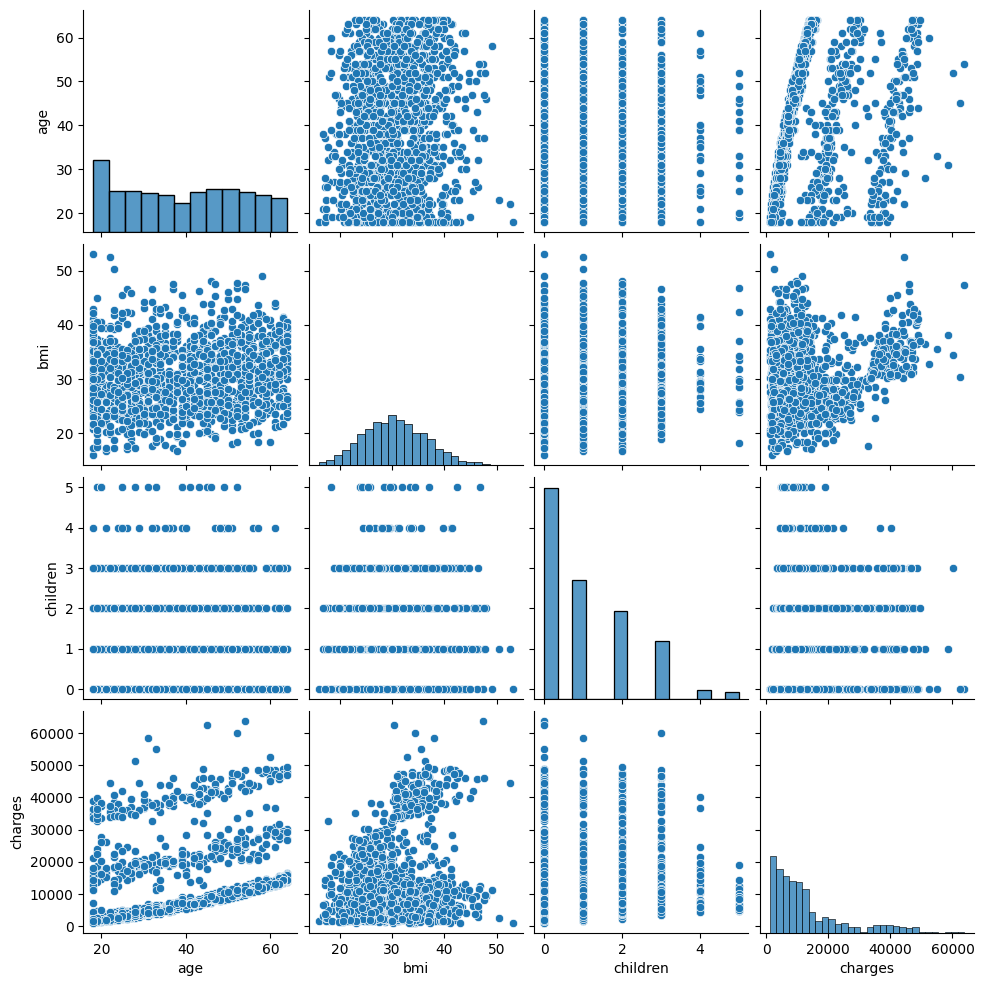

In [17]:
sns.pairplot(numeric)

plt.show()

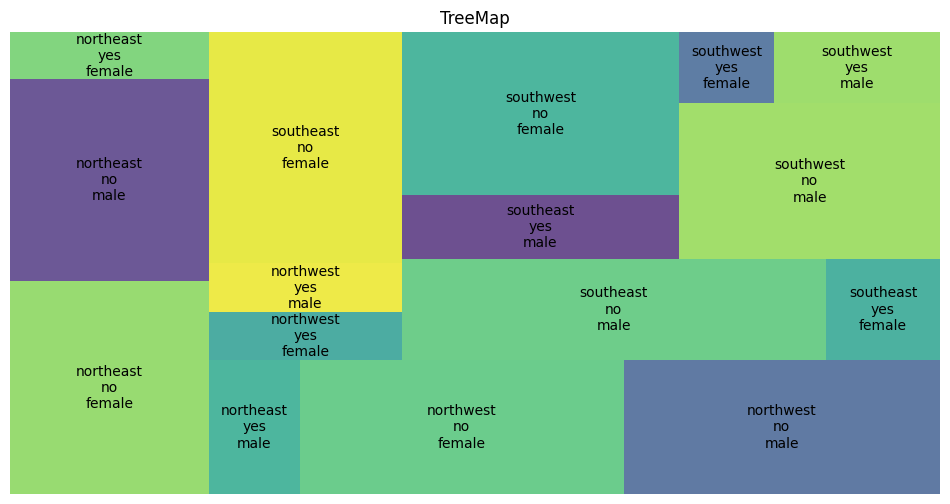

In [18]:
tree = df.groupby(
    ['region','smoker','gender']
).size().reset_index(name='count')

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=tree['count'],
    label=tree['region']+"\n"+tree['smoker']+"\n"+tree['gender'],
    alpha=0.8
)

plt.axis("off")

plt.title("TreeMap")

plt.show()

In [19]:
encoded_df = pd.get_dummies(
    df,
    columns=['gender','smoker','region'],
    drop_first=True
)

encoded_df.head()

,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [21]:
X = encoded_df.drop("charges", axis=1)

y = encoded_df["charges"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test)

In [25]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("MSE :", mean_squared_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R² Score :", r2_score(y_test, predictions))

MAE : 4181.19447375365
MSE : 33596915.85136145
RMSE : 5796.284659276273
R² Score : 0.7835929767120724


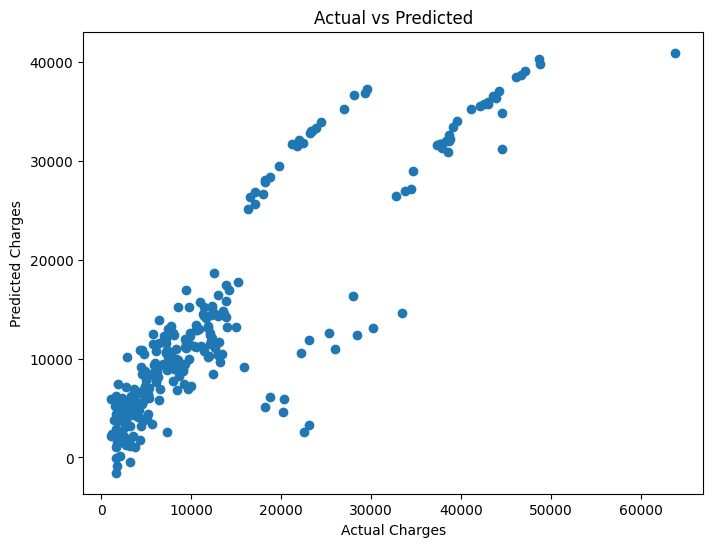

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

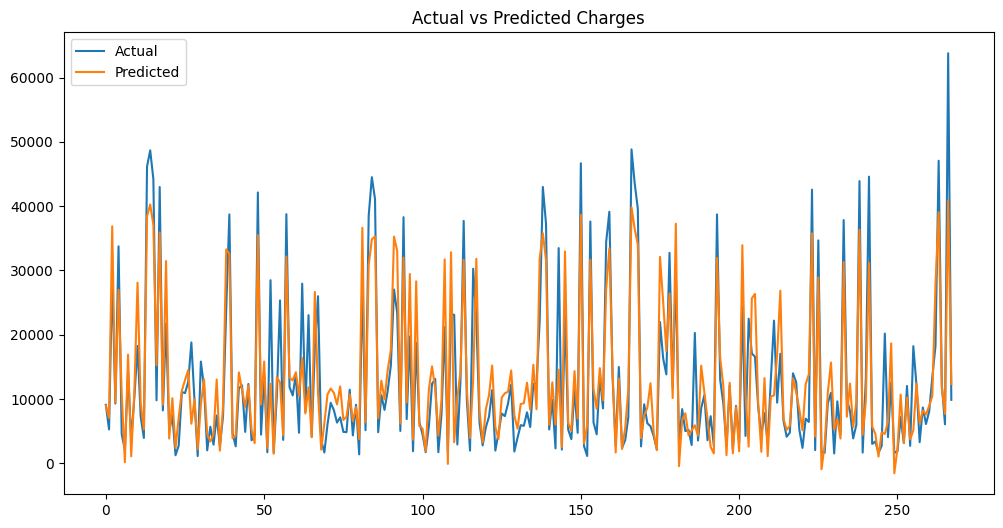

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Charges")

plt.show()

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,gender_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354
